<a href="https://colab.research.google.com/github/LingaAdithya/22MIA1002/blob/main/GLOC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm
from glob import glob

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import albumentations as A

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp

In [ ]:
ROOT = "/content/drive/MyDrive/GLOC"

LABEL_ROOT = os.path.join(
    ROOT,
    "Label_Subset",
    "Class_Labels"
)

MASK_ROOT = os.path.join(
    ROOT,
    "Label_Subset",
    "Ground truth"
)

CHECKPOINT_DIR = os.path.join(ROOT, "checkpoints")
OUTPUT_DIR = os.path.join(ROOT, "outputs")

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
classes = [
    "Cloud Cover",
    "Debris Cover",
    "Moraine",
    "Snow Cover",
    "Terraine Shadow",
    "Turbidity"
]

images = []
masks = []

for cls in classes:

    img_dir = os.path.join(LABEL_ROOT, cls)
    mask_dir = os.path.join(MASK_ROOT, cls)

    for file in os.listdir(img_dir):

        img_path = os.path.join(img_dir, file)
        mask_path = os.path.join(mask_dir, file)

        if os.path.exists(mask_path):

            images.append(img_path)
            masks.append(mask_path)

print("Images:", len(images))
print("Masks :", len(masks))

Images: 60
Masks : 60


In [ ]:
for cls in classes:
    print(cls)
    print("Images:", len(os.listdir(os.path.join(LABEL_ROOT, cls))))
    print("Masks :", len(os.listdir(os.path.join(MASK_ROOT, cls))))
    print()

Cloud Cover
Images: 10
Masks : 10

Debris Cover
Images: 10
Masks : 10

Moraine
Images: 10
Masks : 10

Snow Cover
Images: 10
Masks : 10

Terraine Shadow
Images: 10
Masks : 10

Turbidity
Images: 10
Masks : 10



In [ ]:
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print(len(train_imgs))
print(len(val_imgs))

48
12


In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

val_transform = A.Compose([])

In [ ]:
class LakeDataset(Dataset):

    def __init__(self, images, masks, transform=None):

        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(
            self.masks[idx],
            cv2.IMREAD_GRAYSCALE
        )

        mask = (mask > 0).astype(np.float32)

        if self.transform:

            transformed = self.transform(
                image=image,
                mask=mask
            )

            image = transformed["image"]
            mask = transformed["mask"]

        image = image.astype(np.float32) / 255.0

        image = np.transpose(image, (2,0,1))

        return (
            torch.tensor(image, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        )

In [ ]:
train_ds = LakeDataset(
    train_imgs,
    train_masks,
    train_transform
)

val_ds = LakeDataset(
    val_imgs,
    val_masks,
    val_transform
)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False
)

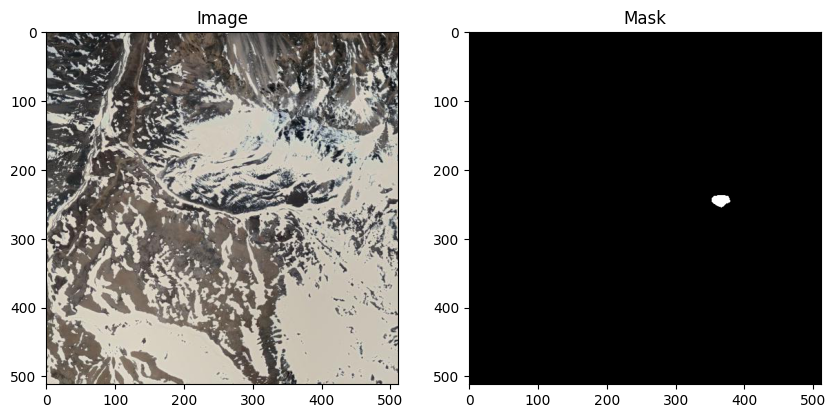

In [ ]:
img, mask = train_ds[0]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img.permute(1,2,0))
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Mask")

plt.show()

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [ ]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1e-6

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    dice = (
        2 * intersection + smooth
    ) / (
        union + smooth
    )

    return 1 - dice

def loss_fn(pred, target):
    return bce(pred,target) + dice_loss(pred,target)

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [ ]:
best_loss = 999

EPOCHS = 40

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(
            outputs,
            masks
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = loss_fn(
                outputs,
                masks
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(
        f"Epoch {epoch+1} | "
        f"Train {train_loss:.4f} | "
        f"Val {val_loss:.4f}"
    )

    if val_loss < best_loss:

        best_loss = val_loss

        torch.save(
            model.state_dict(),
            os.path.join(
                CHECKPOINT_DIR,
                "best_unet.pth"
            )
        )

        print("saved")

Epoch 1 | Train 1.4594 | Val 1.6013
saved
Epoch 2 | Train 1.3921 | Val 1.4668
saved
Epoch 3 | Train 1.3272 | Val 1.3758
saved
Epoch 4 | Train 1.2873 | Val 1.3044
saved
Epoch 5 | Train 1.2294 | Val 1.2501
saved
Epoch 6 | Train 1.1752 | Val 1.2340
saved
Epoch 7 | Train 1.1395 | Val 1.1791
saved
Epoch 8 | Train 1.1169 | Val 1.1791
Epoch 9 | Train 1.0862 | Val 1.2177
Epoch 10 | Train 1.0951 | Val 1.1663
saved
Epoch 11 | Train 1.0296 | Val 1.1666
Epoch 12 | Train 0.9893 | Val 1.1416
saved
Epoch 13 | Train 0.9913 | Val 1.1129
saved
Epoch 14 | Train 0.9768 | Val 1.1022
saved
Epoch 15 | Train 0.9528 | Val 1.0820
saved
Epoch 16 | Train 0.9324 | Val 1.0543
saved
Epoch 17 | Train 0.9217 | Val 1.0482
saved
Epoch 18 | Train 0.9009 | Val 1.0184
saved
Epoch 19 | Train 0.8919 | Val 1.0194
Epoch 20 | Train 0.8711 | Val 1.0493
Epoch 21 | Train 0.8897 | Val 1.0501
Epoch 22 | Train 0.8390 | Val 1.0236
Epoch 23 | Train 0.8227 | Val 0.9878
saved
Epoch 24 | Train 0.7961 | Val 1.0112
Epoch 25 | Train 0.7706 |

In [ ]:
model.load_state_dict(
    torch.load(
        os.path.join(
            CHECKPOINT_DIR,
            "best_unet.pth"
        )
    )
)

<All keys matched successfully>

In [ ]:
def predict(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    inp = image.astype(np.float32)/255.0

    inp = np.transpose(inp,(2,0,1))

    inp = torch.tensor(
        inp,
        dtype=torch.float32
    ).unsqueeze(0)

    inp = inp.to(device)

    model.eval()

    with torch.no_grad():

        pred = model(inp)

        pred = torch.sigmoid(pred)

        pred = pred.squeeze().cpu().numpy()

    return image,pred

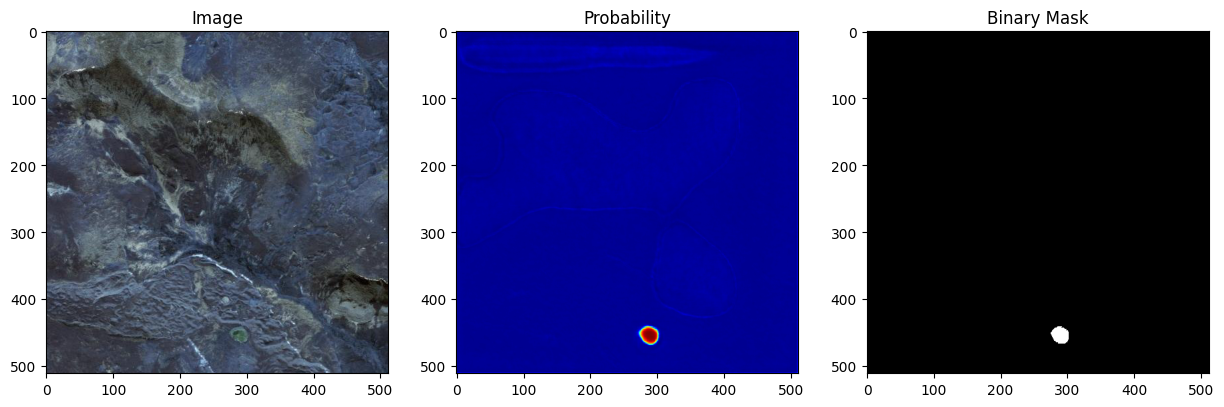

In [ ]:
image,pred = predict(val_imgs[11])

mask = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(pred,cmap="jet")
plt.title("Probability")

plt.subplot(1,3,3)
plt.imshow(mask,cmap="gray")
plt.title("Binary Mask")

plt.show()

In [ ]:
import numpy as np
import torch

def dice_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    return (
        2 * intersection + 1e-6
    ) / (
        pred.sum() + target.sum() + 1e-6
    )

def iou_score(pred, target):

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = (
        pred + target
    ).clamp(0,1).sum()

    return (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

model.eval()

dice_list = []
iou_list = []

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        outputs = torch.sigmoid(outputs)

        dice_list.append(
            dice_score(outputs,masks).item()
        )

        iou_list.append(
            iou_score(outputs,masks).item()
        )

print("Mean Dice:", np.mean(dice_list))
print("Mean IoU :", np.mean(iou_list))

Mean Dice: 0.4872116843859355
Mean IoU : 0.3351357827583949


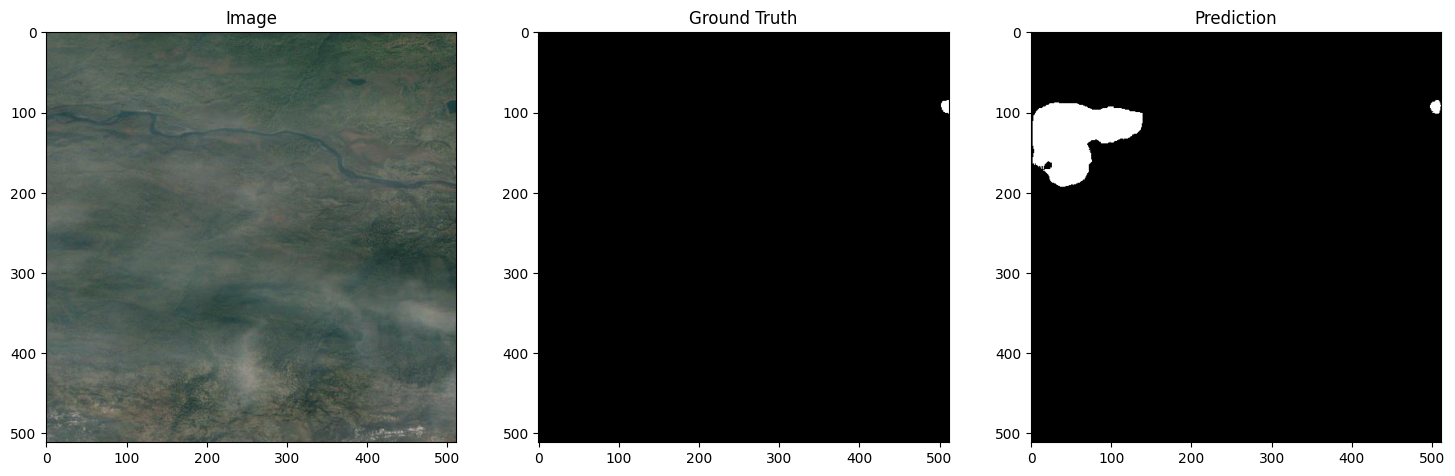

In [ ]:
idx = 0

image = cv2.imread(val_imgs[idx])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

gt = cv2.imread(
    val_masks[idx],
    cv2.IMREAD_GRAYSCALE
)

_, pred = predict(val_imgs[idx])

pred_bin = (pred > 0.5).astype(np.uint8)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,3,2)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred_bin, cmap="gray")
plt.title("Prediction")

plt.show()